In [2]:
from api_dados import coletar_dados
import pandas as pd
import os

nome_produto = 'dados-hidrologicos-res'
CAMINHO_VAZAO = 'dados/dados_vazao_ons.csv'
FORCAR_DOWNLOAD = False

if os.path.exists(CAMINHO_VAZAO) and not FORCAR_DOWNLOAD:
    df = pd.read_csv(CAMINHO_VAZAO)
    print(f"Vazão lida do cache local '{CAMINHO_VAZAO}' ({len(df)} linhas).")
else:
    df = coletar_dados('ons', nome_produto)
    df.to_csv(CAMINHO_VAZAO, index=False)
    print(f"Vazão baixada da API e salva em '{CAMINHO_VAZAO}' ({len(df)} linhas).")

Iniciando download de 27 arquivos...
Vazão baixada da API e salva em 'dados/dados_vazao_ons.csv' (1580467 linhas).


In [2]:
# limitar dados ate 31/12/2025 para reprodutibilidade
df['din_instante'] = pd.to_datetime(df['din_instante'])
df = df[df['din_instante'] <= '2025-12-31']

In [3]:
todos_reservatorios = df['nom_reservatorio'].unique()

print(f'Total de reservatorios no dataset: {len(todos_reservatorios)}')

Total de reservatorios no dataset: 184


In [4]:
import pandas as pd

def preparar_serie_diaria(df, nome_reservatorio):
    """Prepara serie diaria de vazao para um reservatorio."""
    df_res = df[df['nom_reservatorio'] == nome_reservatorio].copy()
    df_res['din_instante'] = pd.to_datetime(df_res['din_instante'])
    df_res['val_vazaonatural'] = pd.to_numeric(df_res['val_vazaonatural'], errors='coerce')
    df_res = df_res.dropna(subset=['val_vazaonatural'])
    
    if len(df_res) == 0:
        return None
    
    df_res = df_res.set_index('din_instante').sort_index()
    serie = df_res['val_vazaonatural'].copy()
    serie = serie[~serie.index.duplicated(keep='first')]
    serie = serie.asfreq('D')
    if serie.isna().any():
        return None
    return serie


print('Pre-filtrando reservatorios...\n')
reservatorios_validos = []
for nome in todos_reservatorios:
    serie_temp = preparar_serie_diaria(df, nome)
    if serie_temp is not None and len(serie_temp) >= 9125:
        reservatorios_validos.append(nome)
    del serie_temp
print(f'{len(reservatorios_validos)} reservatórios válidos\n')

print('Preparando series...')
series_preparadas = {}
for nome in reservatorios_validos:
    serie = preparar_serie_diaria(df, nome)
    if serie is not None:
        series_preparadas[nome] = serie


Pre-filtrando reservatorios...

147 reservatórios válidos

Preparando series...


In [5]:
import numpy as np
from scipy import signal
from scipy import stats

from statsmodels.tsa.stattools import adfuller


def ts_features_dict(series_dict):
    """
    calcula um conjunto ampliado de features para cada série no dicionário.
    retorna um DataFrame com índice = chaves do dicionário e colunas das features.
    """
    rows = []
    for key, vals in series_dict.items():
        # converter para pandas Series numérica
        s = pd.Series(vals).astype(float)
        s = s.dropna()

        x = s.values
        # estatísticas básicas
        mean = np.mean(x)
        std = np.std(x, ddof=0)
        cv = std / mean if mean != 0 else np.nan
        vmin = np.min(x)
        vmax = np.max(x)

        # assimetria e curtose (scipy se disponível)
        skew = stats.skew(x, bias=False)
        kurt = stats.kurtosis(x, fisher=True, bias=False)  # excess kurtosis

        # autocorrelação lag1 (pandas)
        ac1 = pd.Series(x).autocorr(lag=1)

        # slope: regressão linear simples contra índice temporal
        t = np.arange(len(x))
        # ajustar linha t vs x por mínimos quadrados
        A = np.vstack([t, np.ones_like(t)]).T
        m, c = np.linalg.lstsq(A, x, rcond=None)[0]
        slope = float(m)

        # número de picos (eventos locais)
        peaks, _ = signal.find_peaks(x)
        n_peaks = len(peaks)


        rows.append({
            "series": key,
            "mean": mean,
            "std": std,
            "cv": cv,
            "skew": skew,
            "kurtosis": kurt,
            "min": vmin,
            "max": vmax,
            "range": vmax - vmin,
            "ac_lag1": ac1,
            "slope": slope,
            "n_peaks": n_peaks,
        })

    df = pd.DataFrame(rows).set_index("series")
    return df


from sklearn.preprocessing import StandardScaler

X_raw = ts_features_dict(series_preparadas)
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns, index=X_raw.index)
X

,mean,std,cv,skew,kurtosis,min,max,range,ac_lag1,slope,n_peaks
series,,,,,,,,,,,
ITAPEBI,-0.318947,-0.245293,2.177108,0.771062,0.169899,-0.346194,-0.230093,-0.222843,0.262406,0.216914,0.305146
PEDRA DO CAVALO,-0.381682,-0.380109,3.325072,1.743205,1.027888,-0.352998,-0.453257,-0.453759,-0.102696,0.359945,-1.223946
BOA ESPERANÃA,-0.252220,-0.314657,-0.815088,-0.280414,-0.406680,-0.007163,-0.441623,-0.457247,0.534750,0.298890,0.161305
SOBRADINHO,0.296179,0.429336,-0.095668,-0.933691,-0.709340,0.040334,0.215862,0.221843,0.706819,-1.228787,-1.533517
"P. AFONSO 1,2,3",0.313827,0.472304,-0.037095,-0.839938,-0.672378,0.112238,0.643345,0.661531,0.697351,-1.339675,-1.114502
...,...,...,...,...,...,...,...,...,...,...,...
MONJOLINHO,-0.364429,-0.375029,1.140713,1.053445,0.599037,-0.352340,-0.480417,-0.481930,-0.621026,0.478839,0.724161
FOZ CHAPECO,0.169981,0.556367,0.909714,0.646010,0.161319,-0.128562,1.778336,1.848327,-0.153927,0.837581,0.167559
QUEBRA QUEIXO,-0.373771,-0.401406,0.591938,0.741645,0.334657,-0.348951,-0.538931,-0.542709,-0.328881,0.460752,1.308906


In [6]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import optuna

random_state = 18


def spectral_clustering(X, params):
    X = np.asarray(X)

    n_neighbors = int(params.get('n_neighbors'))
    affinity = params.get('affinity')
    n_clusters = int(params.get('n_clusters'))
    n_init = int(params.get('n_init'))

    spec = SpectralClustering(n_clusters=n_clusters, n_neighbors=n_neighbors, affinity=affinity, n_init=n_init, random_state=random_state, assign_labels='kmeans')
    rotulos = spec.fit_predict(X)
    return rotulos


def escolher_hiperparametros(X):
    def objective(trial):
        algo_params = {}
        n_neighbors= trial.suggest_int('n_neighbors', 2, 40)
        affinity= trial.suggest_categorical('affinity', ['nearest_neighbors', 'rbf'])
        n_clusters= trial.suggest_int('n_clusters', 4, 20)
        n_init = trial.suggest_int('n_init', 2, 30)
        algo_params['n_neighbors'] = n_neighbors
        algo_params['affinity'] = affinity
        algo_params['n_clusters'] = n_clusters
        algo_params['n_init'] = n_init

        rotulos = spectral_clustering(X, algo_params)

        n_unique = len(np.unique(rotulos))
        if n_unique < 2:
            return -1

        # penalizar clusters com menos de 3 membros
        counts = np.bincount(rotulos)
        if np.any(counts[counts > 0] < 3):
            return -1

        silhouette = silhouette_score(X, rotulos)
            
        trial.set_user_attr('algo_params', algo_params)

        return silhouette

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=random_state))

    study.optimize(objective, n_trials=500, show_progress_bar=True)

    best = study.best_trial
    best_algo = best.user_attrs.get('algo_params', {})

    return best_algo


hp_algo = escolher_hiperparametros(X)

resultado = spectral_clustering(X, hp_algo)

print(f'\nMelhores hiperparâmetros: {hp_algo}')
print(f'Silhouette score:  {silhouette_score(X, resultado):.4f}')
print(f'Davies-Bouldin:    {davies_bouldin_score(X, resultado):.4f}')
print(f'Número de clusters: {len(np.unique(resultado))}')
print(f'Contagem por cluster: {dict(zip(*np.unique(resultado, return_counts=True)))}')

[I 2026-06-20 15:25:49,660] A new study created in memory with name: no-name-e98bc594-c345-49dc-9f59-94c8d5fbe432


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-06-20 15:25:51,272] Trial 0 finished with value: -1.0 and parameters: {'n_neighbors': 27, 'affinity': 'rbf', 'n_clusters': 7, 'n_init': 26}. Best is trial 0 with value: -1.0.
[I 2026-06-20 15:25:51,281] Trial 1 finished with value: -1.0 and parameters: {'n_neighbors': 31, 'affinity': 'rbf', 'n_clusters': 8, 'n_init': 2}. Best is trial 0 with value: -1.0.
[I 2026-06-20 15:25:51,305] Trial 2 finished with value: 0.1074356212492292 and parameters: {'n_neighbors': 26, 'affinity': 'nearest_neighbors', 'n_clusters': 4, 'n_init': 5}. Best is trial 2 with value: 0.1074356212492292.
[I 2026-06-20 15:25:51,347] Trial 3 finished with value: -1.0 and parameters: {'n_neighbors': 13, 'affinity': 'rbf', 'n_clusters': 7, 'n_init': 21}. Best is trial 2 with value: 0.1074356212492292.
[I 2026-06-20 15:25:51,377] Trial 4 finished with value: -1.0 and parameters: {'n_neighbors': 29, 'affinity': 'rbf', 'n_clusters': 17, 'n_init': 7}. Best is trial 2 with value: 0.1074356212492292.
[I 2026-06-20 15:

c:\Users\PersioPuertasGarciaL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\PersioPuertasGarciaL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[I 2026-06-20 15:25:51,507] Trial 6 finished with value: -1.0 and parameters: {'n_neighbors': 14, 'affinity': 'rbf', 'n_clusters': 18, 'n_init': 18}. Best is trial 2 with value: 0.1074356212492292.
[I 2026-06-20 15:25:51,567] Trial 7 finished with value: 0.2255777950728003 and parameters: {'n_neighbors': 9, 'affinity': 'nearest_neighbors', 'n_clusters': 13, 'n_init': 18}. Best is trial 7 with value: 0.2255777950728003.
[I 2026-06-20 15:25:51,581] Trial 8 finished with value: -0.3235697014596034 and parameters: {'n_neighbors': 2, 'affinity': 'nearest_neighbors', 'n_clusters': 5, 'n_init': 2}. Best is trial 7 with value: 0.2255777950728003.
[I 2026-06-20 15:25:51,599] Trial 9 finished with value: 0.1624922743846255 and parameters: {'n_neighbors': 12, 'affinity': 'nearest_neighbors', 'n_clusters': 5, 'n_init': 2}. Best is trial 7 with value: 0.2255777950728003.
[I 2026-06-20 15:25:51,661] Trial 10 finished with value: -1.0 and parameters: {'n_neighbors': 2, 'affinity': 'nearest_neighbors'

c:\Users\PersioPuertasGarciaL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[I 2026-06-20 15:26:33,917] Trial 357 finished with value: 0.167787667892449 and parameters: {'n_neighbors': 3, 'affinity': 'nearest_neighbors', 'n_clusters': 18, 'n_init': 28}. Best is trial 117 with value: 0.26662963366167425.
[I 2026-06-20 15:26:34,057] Trial 358 finished with value: 0.24714228218352963 and parameters: {'n_neighbors': 25, 'affinity': 'nearest_neighbors', 'n_clusters': 18, 'n_init': 29}. Best is trial 117 with value: 0.26662963366167425.
[I 2026-06-20 15:26:34,197] Trial 359 finished with value: 0.2366010551209067 and parameters: {'n_neighbors': 26, 'affinity': 'nearest_neighbors', 'n_clusters': 16, 'n_init': 30}. Best is trial 117 with value: 0.26662963366167425.
[I 2026-06-20 15:26:34,337] Trial 360 finished with value: 0.23846075271727127 and parameters: {'n_neighbors': 24, 'affinity': 'nearest_neighbors', 'n_clusters': 17, 'n_init': 29}. Best is trial 117 with value: 0.26662963366167425.
[I 2026-06-20 15:26:34,463] Trial 361 finished with value: 0.228268198243676

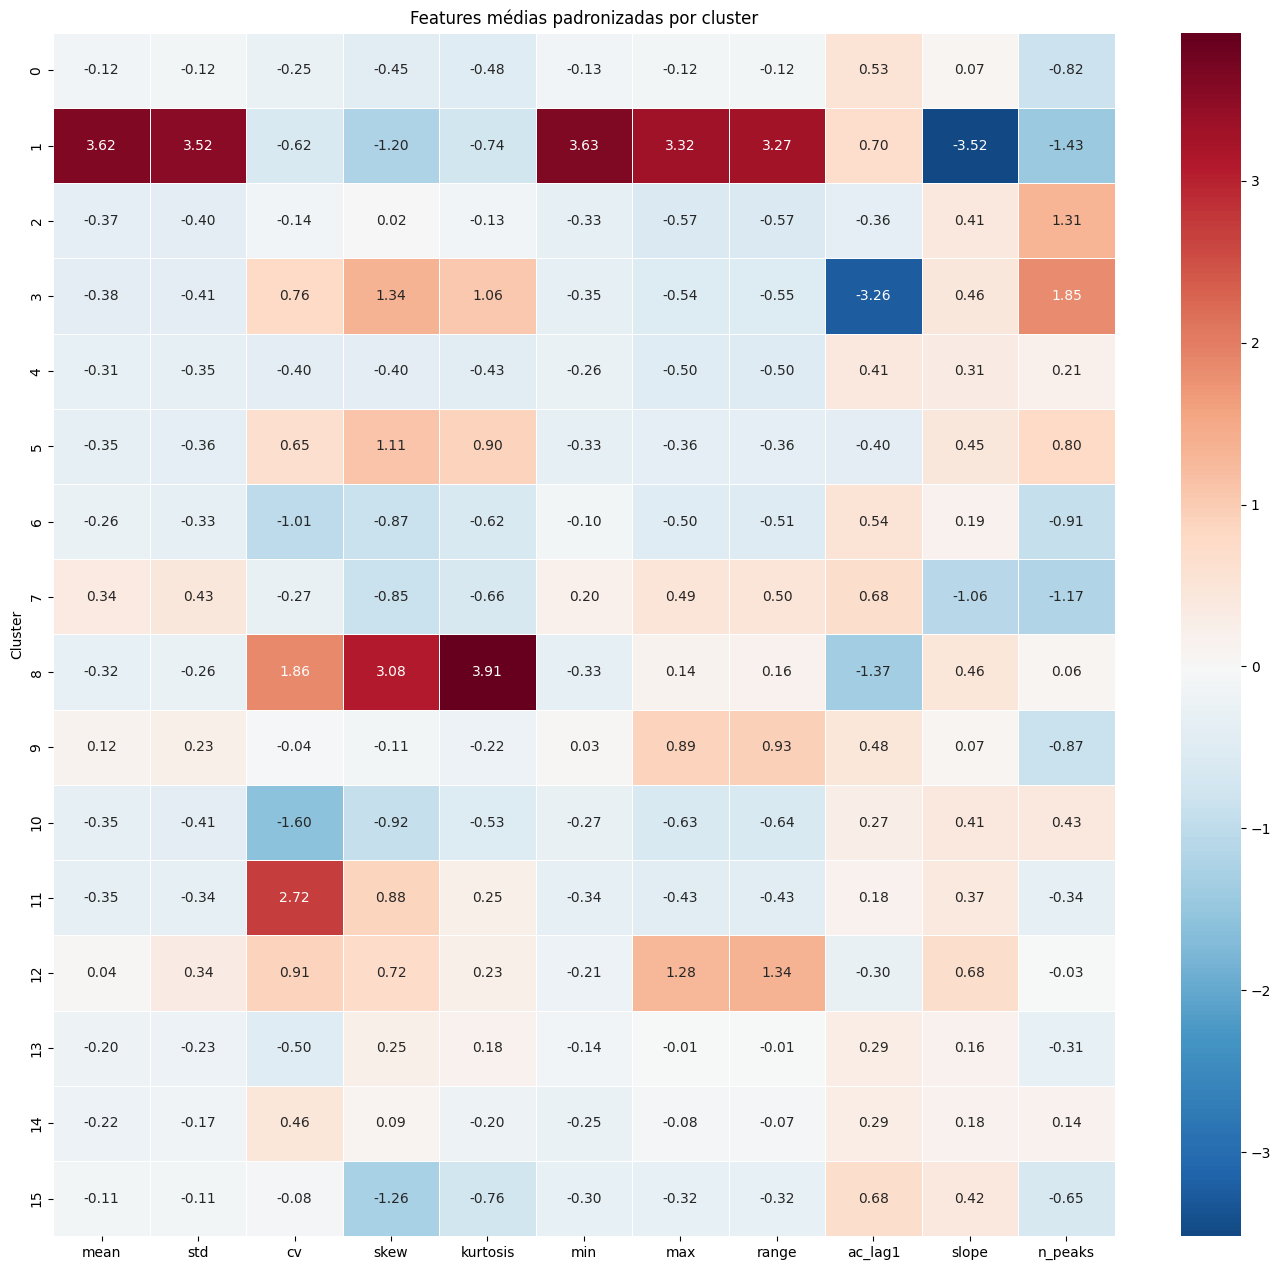

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

labels = np.asarray(resultado)

unique_labels = np.unique(labels)

# --- Heatmap: features médias por cluster ---
df_features = X.copy()
df_features['cluster'] = labels
cluster_means = df_features.groupby('cluster').mean()

fig, ax = plt.subplots(figsize=(14, max(4, len(unique_labels) * 0.8)))
sns.heatmap(cluster_means, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Features médias padronizadas por cluster')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

In [8]:
# --- Análise dos clusters ---
df_analise = X_raw.copy()
df_analise['cluster'] = resultado

# contagem de membros por cluster
print('=== Contagem por cluster ===')
contagem = df_analise['cluster'].value_counts().sort_index()
for c, n in contagem.items():
    print(f'  Cluster {c}: {n} reservatórios')
print(f'  Total: {contagem.sum()}\n')

# features médias (escala original) por cluster
print('=== Features médias por cluster (escala original) ===')
medias = df_analise.groupby('cluster').mean()
display(medias.round(2))

# listar reservatórios por cluster
print('\n=== Reservatórios por cluster ===')
for c in sorted(df_analise['cluster'].unique()):
    nomes = df_analise[df_analise['cluster'] == c].index.tolist()
    print(f'\nCluster {c} ({len(nomes)} reservatórios):')
    for nome in sorted(nomes):
        print(f'  - {nome}')

=== Contagem por cluster ===
  Cluster 0: 17 reservatórios
  Cluster 1: 8 reservatórios
  Cluster 2: 11 reservatórios
  Cluster 3: 9 reservatórios
  Cluster 4: 23 reservatórios
  Cluster 5: 16 reservatórios
  Cluster 6: 4 reservatórios
  Cluster 7: 11 reservatórios
  Cluster 8: 5 reservatórios
  Cluster 9: 7 reservatórios
  Cluster 10: 10 reservatórios
  Cluster 11: 5 reservatórios
  Cluster 12: 3 reservatórios
  Cluster 13: 6 reservatórios
  Cluster 14: 8 reservatórios
  Cluster 15: 4 reservatórios
  Total: 147

=== Features médias por cluster (escala original) ===


,mean,std,cv,skew,kurtosis,min,max,range,ac_lag1,slope,n_peaks
cluster,,,,,,,,,,,
0,723.32,591.84,0.82,2.28,7.42,86.56,5248.51,5161.95,0.98,-0.03,967.12
1,10231.51,6971.14,0.69,1.08,0.92,1574.43,36559.17,34984.74,1.00,-0.26,772.00
2,104.67,91.64,0.85,3.03,16.52,11.02,1158.77,1147.75,0.91,-0.00,1648.00
3,56.39,80.52,1.16,5.14,47.42,0.39,1377.72,1377.33,0.67,0.00,1822.56
4,235.83,177.32,0.76,2.36,8.89,38.49,1803.47,1764.98,0.97,-0.01,1297.91
5,136.15,157.98,1.12,4.78,43.32,8.43,3049.59,3041.16,0.91,-0.00,1485.69
6,385.42,218.11,0.56,1.61,3.79,100.86,1808.90,1708.04,0.98,-0.02,939.75
7,1910.52,1550.11,0.81,1.64,2.95,220.10,10799.93,10579.83,1.00,-0.10,856.00
8,209.58,346.15,1.53,7.93,121.13,7.91,7580.17,7572.27,0.83,0.00,1249.60



=== Reservatórios por cluster ===

Cluster 0 (17 reservatórios):
  - C.BRANCO-1
  - C.BRANCO-2
  - CANA BRAVA
  - FURNAS
  - G. B. MUNHOZ
  - IBITINGA
  - IGARAPAVA
  - JAGUARA
  - L. C. BARRETO
  - M. MORAES
  - N. AVANHANDAVA
  - P. COLOMBIA
  - PROMISSÃO
  - SAO SALVADOR
  - SEGREDO
  - TRÃS IRMÃOS
  - VOLTA GRANDE

Cluster 1 (8 reservatórios):
  - I. SOLTEIRA
  - ITAIPU
  - JIRAU
  - JUPIA
  - PIMENTAL
  - PORTO PRIMAVERA
  - SANTO ANTONIO
  - TUCURUI

Cluster 2 (11 reservatórios):
  - B. BONITA
  - BARRA BRAUNA
  - CORUMBA-4
  - GUARAPIRANGA
  - JAGUARI
  - MANSO
  - PICADA
  - ROSAL
  - SALTO PILAO
  - SANTA BRANCA
  - SOBRAGI

Cluster 3 (9 reservatórios):
  - BARRA GRANDE
  - BILLINGS
  - EDGARD SOUZA
  - ERNESTINA
  - LAJES
  - PEREIRA PASSOS
  - PONTE NOVA
  - SANTANA
  - TOCOS

Cluster 4 (23 reservatórios):
  - ANTA
  - BARIRI
  - BATALHA
  - BOA ESPERANÃA
  - CACONDE
  - CACU
  - CAMARGOS
  - CORUMBA
  - CURUA-UNA
  - E. DA CUNHA
  - EMBORCAÃÃO
  - FUNIL
  - FUNIL-MG


In [9]:
# --- Sorteio de 2 estações por cluster ---
rng = np.random.default_rng(seed=random_state)

print('=== 2 estações sorteadas por cluster ===\n')
sorteados = {}
for c in sorted(df_analise['cluster'].unique()):
    membros = df_analise[df_analise['cluster'] == c].index.tolist()
    n = min(2, len(membros))
    escolhidos = rng.choice(membros, size=n, replace=False).tolist()
    sorteados[c] = escolhidos
    print(f'Cluster {c}: {escolhidos}')

# resumo como DataFrame
df_sorteados = pd.DataFrame([
    {'cluster': c, 'reservatorio': nome}
    for c, nomes in sorteados.items()
    for nome in nomes
])


=== 2 estações sorteadas por cluster ===

Cluster 0: ['P. COLOMBIA', 'SAO SALVADOR']
Cluster 1: ['PORTO PRIMAVERA', 'JUPIA']
Cluster 2: ['PICADA', 'ROSAL']
Cluster 3: ['ERNESTINA', 'EDGARD SOUZA']
Cluster 4: ['BATALHA', 'EMBORCAÃ\x87Ã\x83O']
Cluster 5: ['D. FRANCISCA', 'G. P. SOUZA']
Cluster 6: ['B.COQUEIROS', 'COLIDER']
Cluster 7: ['XINGO', 'A. VERMELHA']
Cluster 8: ['CASTRO ALVES', '14 DE JULHO']
Cluster 9: ['SALTO OSORIO', 'SALTO CAXIAS']
Cluster 10: ['ESPORA', 'BALBINA']
Cluster 11: ['IRAPE', 'ITAPEBI']
Cluster 12: ['FOZ CHAPECO', 'ITÃ\x81']
Cluster 13: ['CAPIVARA', 'CANOAS II']
Cluster 14: ['SERRA DA MESA', 'GARIBALDI']
Cluster 15: ['DARDANELOS', 'SAMUEL']


In [10]:
df2= coletar_dados('ons', 'reservatorio')

Iniciando download de 1 arquivos...


In [11]:
# --- mapa de localizacao dos reservatorios ---

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import numpy as np

# filtrar apenas reservatorios usados no experimento
nomes_usados = set(df_sorteados['reservatorio'].unique())
df_mapa = df2[df2['nom_reservatorio'].isin(nomes_usados)].copy()
df_mapa['val_latitude'] = pd.to_numeric(df_mapa['val_latitude'], errors='coerce')
df_mapa['val_longitude'] = pd.to_numeric(df_mapa['val_longitude'], errors='coerce')
df_mapa = df_mapa.dropna(subset=['val_latitude', 'val_longitude'])

# diagnosticar nomes ausentes
nomes_encontrados = set(df_mapa['nom_reservatorio'].unique())
nomes_faltantes = nomes_usados - nomes_encontrados
if nomes_faltantes:
    print(f'Reservatórios NÃO encontrados em df2: {nomes_faltantes}')
    todos_nomes_df2 = sorted(df2['nom_reservatorio'].unique())
    print(f'\nTodos os nomes em df2 ({len(todos_nomes_df2)}):')
    for n in todos_nomes_df2:
        print(f'  {repr(n)}')
else:
    print('Todos os reservatórios de nomes_usados foram encontrados em df2.')

# remover duplicatas (manter primeira ocorrencia por reservatorio)
df_mapa = df_mapa.drop_duplicates(subset='nom_reservatorio', keep='first')



Reservatórios NÃO encontrados em df2: {'ERNESTINA', 'EDGARD SOUZA'}

Todos os nomes em df2 (158):
  '14 DE JULHO'
  'A. VERMELHA'
  'AIMORES'
  'ANTA'
  'APOLONIO SALES'
  'B. BONITA'
  'B.COQUEIROS'
  'BAGUARI'
  'BAIXO IGUACU'
  'BALBINA'
  'BARIRI'
  'BARRA BRAUNA'
  'BARRA GRANDE'
  'BATALHA'
  'BELO MONTE'
  'BOA ESPERANÃ\x87A'
  'C. DOURADA'
  'C.BRANCO-1'
  'C.BRANCO-2'
  'CACHOEIRA CALDEIRAO'
  'CACONDE'
  'CACU'
  'CAMARGOS'
  'CAMPOS NOVOS'
  'CANA BRAVA'
  'CANASTRA'
  'CANDONGA'
  'CANOAS I'
  'CANOAS II'
  'CAPIVARA'
  'CASTRO ALVES'
  'CHAVANTES'
  'COARACY NUNES'
  'COLIDER'
  'CORUMBA'
  'CORUMBA-3'
  'CORUMBA-4'
  'CURUA-UNA'
  'D. FRANCISCA'
  'DARDANELOS'
  'E. DA CUNHA'
  'EMBORCAÃ\x87Ã\x83O'
  'ESPORA'
  'ESTREITO'
  'FERREIRA GOMES'
  'FONTES'
  'FOZ CHAPECO'
  'FOZ DO RIO CLARO'
  'FUNDÃ\x83O'
  'FUNIL'
  'FUNIL-MG'
  'FURNAS'
  'G. B. MUNHOZ'
  'G. P. SOUZA'
  'GARIBALDI'
  'GOV JAYME CANET JR'
  'GUAPORE'
  'GUILM. AMORIM'
  'HENRY BORDEN'
  'I. SOLTEIRA'
  'IB

In [12]:
### adicionar manualmente (não encontrados em df2)


if 'BILLINGS' not in df_mapa['nom_reservatorio'].values:
    tocos = pd.DataFrame([{
        'nom_reservatorio': 'BILLINGS',
        'val_latitude': -28.555833472573816,
        'val_longitude': -52.54556151260343,
    }])
    df_mapa = pd.concat([df_mapa, tocos], ignore_index=True)


if 'PONTE NOVA' not in df_mapa['nom_reservatorio'].values:
    tocos = pd.DataFrame([{
        'nom_reservatorio': 'PONTE NOVA',
        'val_latitude': -23.454429295624024,
        'val_longitude': -46.90981831465859,
    }])
    df_mapa = pd.concat([df_mapa, tocos], ignore_index=True)


print(f'\nReservatórios no mapa (únicos): {len(df_mapa)}')



Reservatórios no mapa (únicos): 32


In [ ]:
# --- exportar coordenadas de df_mapa para o mapa em R ---

df_exp = (
    df_mapa[['nom_reservatorio', 'val_latitude', 'val_longitude']]
    .rename(columns={'nom_reservatorio': 'nome_uhe',
                     'val_latitude': 'lat',
                     'val_longitude': 'long'})
)

df_exp.to_csv(r"C:\Users\PersioPuertasGarciaL\Documents\Codigos\trabalhando\merge teste\dados\coordenadasUHEs_clustering.csv", index=False, encoding='utf-8-sig')
